# Problem Statement

Walmart aims to analyze customer purchasing behaviour to understand if spending habits differ between genders and other factors like marital status and age. This insight will help walmart make data-driven decisions to improve customer targetting and optimize sales strategies.

In [94]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t
from IPython.display import display

In [95]:
#Load the dataset
data = pd.read_csv('/Users/tonmoydutta/Library/CloudStorage/OneDrive-Personal/Study Material/Self Elearning/Scaler/Case Study/Wallmart Case Study/walmart_data.csv')
df = pd.DataFrame(data)

# Data Overview

In [96]:
#Data Overview
display("Data Overview:\n", df.head())

'Data Overview:\n'

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [97]:
display("Shape of the Dataset:\n", df.shape)

'Shape of the Dataset:\n'

(550068, 10)

In [98]:
display("Column Information:\n", df.columns)

'Column Information:\n'

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='object')

In [99]:
print("Information:\n",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB
Information:
 None


In [100]:
display("Statistical Summary:\n", df.describe())

'Statistical Summary:\n'

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


# Gender Analysis

In [101]:
#Gender-wise Unique Users and their purchasing capacity
unique_users = df.groupby('Gender')['User_ID'].nunique()
purchase_mean = df.groupby('Gender')['Purchase'].mean()
total_purchase_mean = purchase_mean.sum()
purchase_percentage = (purchase_mean/unique_users)*100

gender_summary_table = pd.DataFrame({'Unique Gender Users':unique_users, 'Gender-wise Purchase Mean':total_purchase_mean, "Gender-wise Purchase Percentage":purchase_percentage})
display(gender_summary_table)

,Unique Gender Users,Gender-wise Purchase Mean,Gender-wise Purchase Percentage
Gender,,,
F,1666,18172.091806,524.283659
M,4225,18172.091806,223.373397


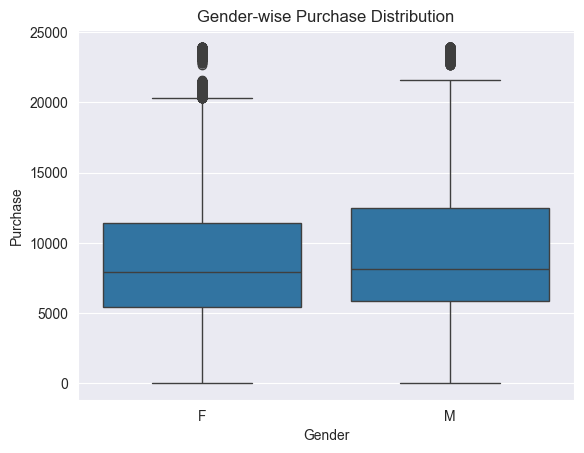

In [102]:
#Gender-wise Purchase Distribution
sns.boxplot(x = 'Gender', y = 'Purchase', data = df)
plt.title("Gender-wise Purchase Distribution")
plt.show()

Inference:
- Male customers slightly outnumber female customers. However, the difference is marginal. ensuring that gender-specific campaigns could benefit both groups.
- Male customers spend more per transaction on average compared to female customers.

# Age Group Analysis

In [103]:
#Age-wise Unique Users and their purchasing capacity
agewise_users = df.groupby('Age')['User_ID'].nunique()
average_spending_age = df.groupby('Age')['Purchase'].mean()
total_spending_age = df.groupby('Age')['Purchase'].sum()
percentage_age_spending = (total_spending_age/total_spending_age.sum())*100

age_summary_table = pd.DataFrame({'Unique Users': agewise_users, 'Age-wise Purchase Mean': average_spending_age, "Age-wise Purchase Percentage":percentage_age_spending})
display(age_summary_table)

,Unique Users,Age-wise Purchase Mean,Age-wise Purchase Percentage
Age,,,
0-17,218,8933.464640,2.647530
18-25,1069,9169.663606,17.933325
26-35,2053,9252.690633,39.871374
36-45,1167,9331.350695,20.145361
46-50,531,9208.625697,8.258612
51-55,481,9534.808031,7.203947
55+,372,9336.280459,3.939850


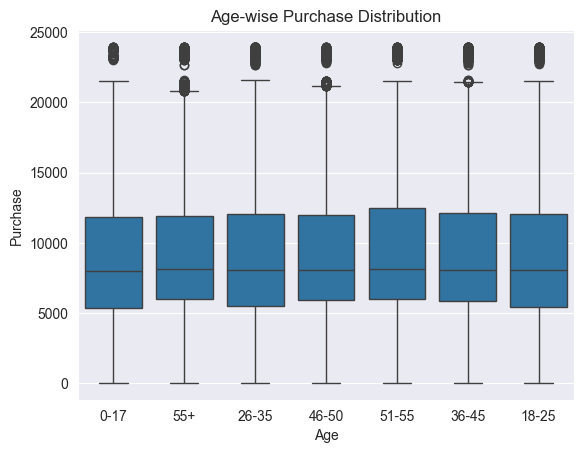

In [104]:
# Age-wise Purchase Distribution
sns.boxplot(x = 'Age', y = 'Purchase', data = df)
plt.title("Age-wise Purchase Distribution")
plt.show()

Inference:
- Customers in the age group "26-35", "36-45" and "18-25" contribute the most to the total spending, indicating high purchasing power and engagement.
- Age group "0-17" and "55+ suggest potential untapped opportunities.

# Marital Status Analysis

In [120]:
marital_status_summary = df.groupby('Marital_Status').agg(
    Unique_Marital_status_users = ('User_ID', 'nunique'),
    Average_Spending = ('Purchase', 'mean'),
    Total_Purchase = ('Purchase', 'sum')
).reset_index()

total_spending_maritalstatus = marital_status_summary['Total_Purchase'].sum()
marital_status_summary['Percentage_Spending'] = (marital_status_summary['Total_Purchase']/total_spending_maritalstatus)*100

display(marital_status_summary)

,Marital_Status,Unique_Marital_status_users,Average_Spending,Total_Purchase,Percentage_Spending
0,0,3417,9265.907619,3008927447,59.047057
1,1,2474,9261.174574,2086885295,40.952943


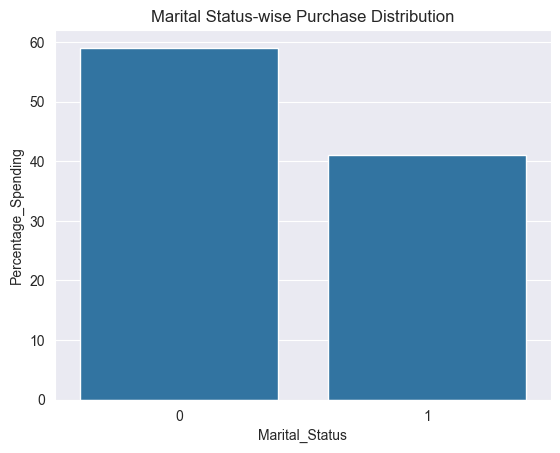

In [123]:
#Marital Status wise Purchase Distribution
sns.barplot(x = 'Marital_Status', y = 'Percentage_Spending', data = marital_status_summary)
plt.title("Marital Status-wise Purchase Distribution")
plt.show()

Inference:
- Married Customers spend less on average compared to unmarried ones.
- Campaign targetting unmarried ones can drive higher engagement.

# City-Wise Analysis

In [126]:
#City-wise Unique Users and their purchasing capacity
citywise_users = df.groupby('City_Category')['User_ID'].nunique()
average_spending_citywise = df.groupby('City_Category')['Purchase'].mean()
total_spending_city = df.groupby('City_Category')['Purchase'].sum()
percentage_city_spending = (total_spending_city/total_spending_city.sum())*100

city_summary_table = pd.DataFrame({'Unique Users': citywise_users, 'Age-wise Purchase Mean': average_spending_citywise, "City-wise Purchase Percentage":percentage_city_spending})
display(city_summary_table)

,Unique Users,Age-wise Purchase Mean,City-wise Purchase Percentage
City_Category,,,
A,1045,8911.939216,25.834381
B,1707,9151.300563,41.515136
C,3139,9719.920993,32.650483


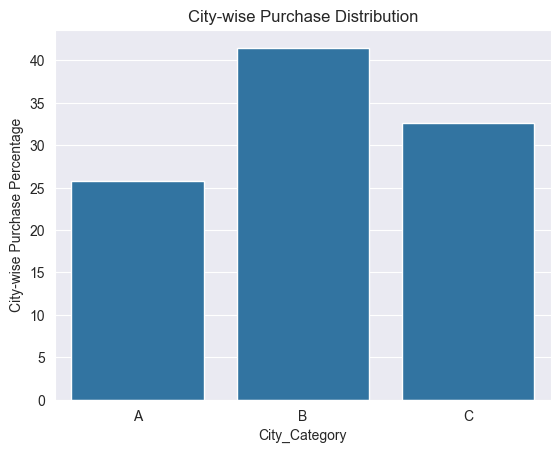

In [127]:
#Citywise Purchase Percentage
sns.barplot(x = 'City_Category', y = 'City-wise Purchase Percentage', data = city_summary_table)
plt.title("City-wise Purchase Distribution")
plt.show()

Inference
- City B shows the highest average spending, followed by C and A.
- Region specific promotions can help increase spending in underperforming city categories (A).

# Confidence Interval Calculations

In [106]:
# Confidence Interval
def confidence_interval(df, confidence = 0.95):
    mean = np.mean(df)
    std_err = np.std(df, ddof=1) / np.sqrt(len(df))
    margin = std_err * t.ppf((1 + confidence) / 2, len(df) - 1)
    return mean - margin, mean + margin

# Calculating Confidence Interval for male and female
male_purchase = df[df['Gender'] == 'M']['Purchase']
female_purchase = df[df['Gender'] == 'F']['Purchase']

ci_male = confidence_interval(male_purchase)
ci_female = confidence_interval(female_purchase)

ci_gender_table = pd.DataFrame({"Gender": ["Male", "Female"], "Lower Bound": [ci_male[0], ci_male[1]], "Upper Bound": [ci_female[0], ci_female[1]]})
display(ci_gender_table)

,Gender,Lower Bound,Upper Bound
0,Male,9422.019402,8709.211321
1,Female,9453.032679,8759.920209


Inference
- Unique Users: Male customers slightly outnumber female customers, but the difference is marginal.
- Average Spending: Male customers spend more on average per transaction compared to females.
- Confidence Intervals: Overlapping confidence intervals for male and female spending indicate no statistically significant difference in spending behavior.
- Recommendation: Walmart can create gender-specific promotions to equally engage male and female customers during Black Friday.

In [107]:
# Age wise Confidence Interval
ci_agegroup = []

for age in df['Age'].unique():
    age_data = df[df['Age'] == age]['Purchase']
    ci_age = confidence_interval(age_data)
    ci_agegroup.append({
        "Age Group": age,
        "Lower Bound": ci_age[0],
        "Upper Bound": ci_age[1]
    })

ci_age_table = pd.DataFrame(ci_agegroup).sort_values(by='Lower Bound', ascending=True)

display(ci_age_table)

,Age Group,Lower Bound,Upper Bound
0,0-17,8851.941436,9014.987845
6,18-25,9138.407569,9200.919643
3,46-50,9163.083936,9254.167458
2,26-35,9231.733561,9273.647705
1,55+,9269.295064,9403.265855
5,36-45,9301.669084,9361.032305
4,51-55,9483.989875,9585.626187


Inference
- Older age groups shows lower spending capacity due to diverse priority and incomes. However, younger age group shows consistent spending behaviours
- Walmart can focus marketing efforts on 18-45 age groups while designing specialized campaigns to encourage spending in younger (0-17) and older (55+) segments
- Confidence Intervals:
    - Younger age groups (18-45) show consistent spending behavior with narrower confidence intervals.
    - Older age groups have wider intervals, indicating greater variability due to diverse priorities and incomes.
- Recommendation:
    - Focus marketing efforts on 18-45 age groups to maximize engagement.
    - Develop targeted campaigns to encourage spending in 0-17 (e.g., toys, games) and 55+ segments (e.g., health products).

In [108]:
# Marital Status wise Confidence Interval

ci_maritalstatus = []

for status in df['Marital_Status'].unique():
    spending_data = df[df['Marital_Status'] == status]['Purchase']
    ci = confidence_interval(spending_data)
    ci_maritalstatus.append({"Marital_Status": status, "Lower Bound": ci[0], "Upper Bound": ci[1]})

ci_maritalstatus_table = pd.DataFrame(ci_maritalstatus).sort_values(by='Lower Bound', ascending=True)

display(ci_maritalstatus_table)

,Marital_Status,Lower Bound,Upper Bound
1,1,9240.460316,9281.888832
0,0,9248.616354,9283.198884


Inference:

- Spending Behavior: Unmarried customers spend more on average compared to married ones.
- Confidence Intervals: Spending by unmarried customers shows a narrower range, indicating consistent behavior.
- Recommendation:
    - Target unmarried customers with personalized campaigns (e.g., gadgets, electronics).
    - For married customers, offer family-oriented promotions (e.g., groceries, household essentials).

In [129]:
# City wise Confidence Interval

ci_city = []

for city in df['City_Category'].unique():
    city_data = df[df['City_Category'] == city]['Purchase']
    ci = confidence_interval(city_data)
    ci_city.append({"City_Category": city, "Lower Bound": ci[0], "Upper Bound": ci[1]})

ci_city_table = pd.DataFrame(ci_city).sort_values(by = 'Lower Bound', ascending=True)
display(ci_city_table)

,City_Category,Lower Bound,Upper Bound
0,A,8886.991621,8936.886811
2,B,9131.099743,9171.501382
1,C,9695.336934,9744.505052


Inference:

- Spending by City Category:
    - City B shows the highest average spending, followed by City C and City A.
    - City A has the lowest spending percentage, indicating untapped potential.
- Confidence Intervals: Spending variability is higher in City B and C compared to City A.
- Recommendation:
    - Focus on increasing engagement in City A through region-specific promotions.
    - Retain high spenders in City B with loyalty programs.

# Recommendations

1.	Gender-Specific Promotions:
- Create offers that appeal equally to male and female customers, as their spending behavior shows no significant statistical difference.

2. Age Group Targeting:
- Design campaigns that prioritize high-spending age groups (18-45).
- Incentivize lower-spending segments (0-17, 55+) with targeted offers.

3. Marital Status-Based Offers:
- Encourage unmarried customers with discounts on gadgets and lifestyle products.
- Promote family-oriented discounts and bundles for married customers.

4. City-Specific Strategies:
- Develop targeted marketing initiatives to boost spending in underperforming City A.
- Offer loyalty rewards in City B to maintain engagement among high spenders.

5. Leverage Confidence Intervals:
- Use the confidence interval insights to identify which customer groups exhibit consistent behavior and focus marketing efforts on them for predictable ROI.

